## RNN과 CNN을 이용한 텍스트 분류


In [ ]:
# !pip install scikit-learn numpy scipy
# !pip install pandas
# !pip install --upgrade pip
# !pip install matplotlib
# !pip install konlpy
# !pip install tqdm
# !pip install unidic-lite
# !pip install --no-binary :all: mecab-python3

In [2]:
# LSTM을 이용한 네이버 영화 리뷰 분류
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import urllib.request
from konlpy.tag import Mecab
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from collections import Counter

In [3]:
# 데이터 로드 
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")


('ratings_test.txt', <http.client.HTTPMessage at 0x125bb8a90>)

In [4]:
train_data = pd.read_table('ratings_train.txt')
test_data = pd.read_table('ratings_test.txt')

In [5]:
print('훈련용 리뷰 개수 :', len(train_data))
print(train_data[:5])

훈련용 리뷰 개수 : 150000
         id                                           document  label
0   9976970                                아 더빙.. 진짜 짜증나네요 목소리      0
1   3819312                  흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나      1
2  10265843                                  너무재밓었다그래서보는것을추천한다      0
3   9045019                      교도소 이야기구먼 ..솔직히 재미는 없다..평점 조정      0
4   6483659  사이몬페그의 익살스런 연기가 돋보였던 영화!스파이더맨에서 늙어보이기만 했던 커스틴 ...      1


In [6]:
# 데이터 정제
# document 열과 label 열의 중복을 제외한 값의 개수
train_data.drop_duplicates(subset=['document'],inplace=True)
print('총 샘플의 수 :',len(train_data))

총 샘플의 수 : 146183


<Axes: xlabel='label'>

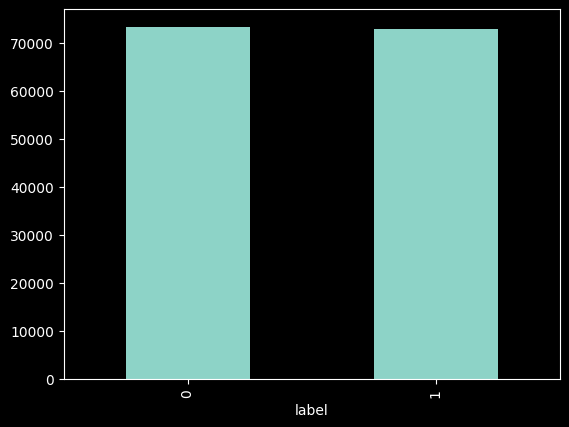

In [7]:
# label 분포
train_data['label'].value_counts().plot(kind='bar')

In [8]:
print(train_data.groupby('label').size().reset_index(name='count'))

   label  count
0      0  73342
1      1  72841


In [9]:
train_data.isnull().sum()

id          0
document    1
label       0
dtype: int64

In [10]:
train_data.loc[train_data.document.isnull()]

,id,document,label
25857,2172111,NaN,1


In [11]:
train_data = train_data.dropna(how='any')
print(train_data.isnull().values.any())

False


In [12]:
print(len(train_data))

146182


In [13]:
# 한글과 공백을 제외하고 모두 제거
train_data['document'] = train_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","",regex=True)
train_data[:5]

,id,document,label
0,9976970,아 더빙 진짜 짜증나네요 목소리,0
1,3819312,흠포스터보고 초딩영화줄오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0
3,9045019,교도소 이야기구먼 솔직히 재미는 없다평점 조정,0
4,6483659,사이몬페그의 익살스런 연기가 돋보였던 영화스파이더맨에서 늙어보이기만 했던 커스틴 던...,1


In [14]:
train_data['document'] = train_data['document'].str.replace('^ +',"",regex=True)
train_data['document'].replace('', np.nan, inplace=True)
print(train_data.isnull().sum())

id            0
document    789
label         0
dtype: int64


/var/folders/m5/8hy8yjzn7kj7v2vfxdvj1j7r0000gn/T/ipykernel_8127/91620825.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_data['document'].replace('', np.nan, inplace=True)


In [15]:
train_data.loc[train_data.document.isnull()][:5]

,id,document,label
404,4221289,NaN,0
412,9509970,NaN,1
470,10147571,NaN,1
584,7117896,NaN,0
593,6478189,NaN,0


In [16]:
train_data = train_data.dropna(how = 'any')
print(len(train_data))

145393


In [17]:
test_data.drop_duplicates(subset = ['document'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거
test_data['document'] = test_data['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","", regex=True) # 정규 표현식 수행
test_data['document'] = test_data['document'].str.replace('^ +', "", regex=True) # 공백은 empty 값으로 변경
test_data['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경
test_data = test_data.dropna(how='any') # Null 값 제거
print('전처리 후 테스트용 샘플의 개수 :',len(test_data))


전처리 후 테스트용 샘플의 개수 : 48852


/var/folders/m5/8hy8yjzn7kj7v2vfxdvj1j7r0000gn/T/ipykernel_8127/4143273380.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경


In [28]:
# 토큰화
stopwords = ['도', '는', '다', '의', '가', ''
'이', '은', '한', '에', '하', '고', '을', '를', 
'인', '듯', '과', '와', '네', '들', '듯', '지', '임', '게']
mecab = Mecab('/opt/homebrew/lib/mecab/dic/mecab-ko-dic')

X_train = []
for sentence in tqdm(train_data['document']):
    tokenized_sentence = mecab.morphs(sentence) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_train.append(stopwords_removed_sentence)

print(X_train[:3])

100%|██████████| 145393/145393 [00:03<00:00, 42188.72it/s]

[['아', '더', '빙', '진짜', '짜증', '나', '네요', '목소리'], ['흠', '포스터', '보고', '초딩', '영화', '줄', '오버', '연기', '조차', '가볍', '않', '구나'], ['너무', '재', '밓었다그래서보는것을추천한다']]


In [30]:
X_test = []
for sentence in tqdm(test_data['document']):
    tokenized_sentence = mecab.morphs(sentence)
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords]
    X_test.append(stopwords_removed_sentence)

100%|██████████| 48852/48852 [00:01<00:00, 45310.57it/s]


In [31]:
y_train = np.array(train_data['label'])
y_test = np.array(test_data['label'])

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size =0.2, random_state=0, stratify=y_train)

In [32]:
print('--------학습 데이터의 비율-----------')
print(f'부정 리뷰 = {round(np.sum(y_train==0)/len(y_train) * 100,3)}%')
print(f'긍정 리뷰 = {round(np.count_nonzero(y_train)/len(y_train) * 100,3)}%')
print('--------검증 데이터의 비율-----------')
print(f'부정 리뷰 = {round(np.sum(y_valid==0)/len(y_valid) * 100,3)}%')
print(f'긍정 리뷰 = {round(np.count_nonzero(y_valid)/len(y_valid) * 100,3)}%')
print('--------테스트 데이터의 비율-----------')
print(f'부정 리뷰 = {round(np.sum(y_test==0)/len(y_test) * 100,3)}%')
print(f'긍정 리뷰 = {round(np.count_nonzero(y_test)/len(y_test) * 100,3)}%')


--------학습 데이터의 비율-----------
부정 리뷰 = 50.238%
긍정 리뷰 = 49.762%
--------검증 데이터의 비율-----------
부정 리뷰 = 50.239%
긍정 리뷰 = 49.761%
--------테스트 데이터의 비율-----------
부정 리뷰 = 49.808%
긍정 리뷰 = 50.192%


In [33]:
# 단어 집합 만들기
word_list = []
for sent in X_train:
    for word in sent:
        word_list.append(word)
word_counts = Counter(word_list)
print('총 단어수 :',len(word_counts))

총 단어수 : 45296


In [34]:
print('훈련 데이터에서의 단어 영화의 등장 횟수 :', word_counts['영화'])
print('훈련 데이터에서의 단어 공감의 등장 횟수 :', word_counts['공감'])

훈련 데이터에서의 단어 영화의 등장 횟수 : 45791
훈련 데이터에서의 단어 공감의 등장 횟수 : 756


In [35]:
vocab = sorted(word_counts, key=word_counts.get, reverse=True)
print('등장 빈도수 상위 10개 단어')
print(vocab[:10])

등장 빈도수 상위 10개 단어
['영화', '보', '있', '없', '좋', '나', '었', '만', '는데', '너무']


In [36]:
# 빈도수 낮은 단어 제외
threshold = 3
total_cnt = len(word_counts)
rare_cnt = 0 
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받음
for key,value in word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value
print('단어 집합의 크기 :', total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수 : %s'%(threshold -1, rare_cnt))
print('단어 집합에서 희귀 단어의 비율:', (rare_cnt/total_cnt)*100)
print('전체 등장 빈도에서 희귀 단어 등장 빈도 비율:', (rare_freq/total_freq)*100)

단어 집합의 크기 : 45296
등장 빈도가 2번 이하인 희귀 단어의 수 : 26104
단어 집합에서 희귀 단어의 비율: 57.62981278700106
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 2.2768269150096483


In [45]:
# 전체 단어 개수 중 빈도수 2이하인 단어는 제거
vocab_size = total_cnt - rare_cnt
vocab = vocab[:vocab_size]
print('단어 집합의 크기:',len(vocab))

단어 집합의 크기: 19192


In [46]:
word_to_index = {}
word_to_index['<PAD>'] = 0 
word_to_index['<UNK>'] = 1

In [47]:
for index, word in enumerate(vocab):
    word_to_index[word] = index + 2

In [48]:
vocab_size = len(word_to_index)
print('패딩과 UNK 토큰을 고려한 단어 집합의 크기 :', vocab_size)

패딩과 UNK 토큰을 고려한 단어 집합의 크기 : 19194


In [49]:
print('단어 <PAD>와 맵핑되는 정수 :', word_to_index['<PAD>'])
print('단어 <UNK>와 맵핑되는 정수 :', word_to_index['<UNK>'])
print('단어 영화와 맵핑되는 정수 :', word_to_index['영화'])


단어 <PAD>와 맵핑되는 정수 : 0
단어 <UNK>와 맵핑되는 정수 : 1
단어 영화와 맵핑되는 정수 : 2


In [50]:
# 정수 인코딩
# 단어 집합에 존재하지 않는 단어들은 <UNK>로 맵핑 
def texts_to_sequences(tokenized_X_data, word_to_index):
    encoded_X_data = []
    for sent in tokenized_X_data:
        index_sequences = []
        for word in sent:
            try:
                index_sequences.append(word_to_index[word])
            except KeyError:
                index_sequences.append(word_to_index['<UNK>'])
        encoded_X_data.append(index_sequences)
    return encoded_X_data

In [51]:
encoded_X_train = texts_to_sequences(X_train, word_to_index)
encoded_X_valid = texts_to_sequences(X_valid, word_to_index)
encoded_X_test = texts_to_sequences(X_test, word_to_index)

In [52]:
for sent in encoded_X_train[:2]:
    print(sent)

[924, 1866, 128, 7, 80, 48, 34]
[2415, 3138, 4, 2095, 422, 87, 5768, 19, 307]


In [53]:
# 정수 인코딩 다시 텍스트로 변환
index_to_word = {}
for key, value in word_to_index.items():
    index_to_word[value] = key

In [55]:
decoded_sample = [index_to_word[word] for word in encoded_X_train[0]]
print('기존의 첫번째 샘플 :', encoded_X_train[0])
print('복원된 첫번쨰 샘플 :', decoded_sample)

기존의 첫번째 샘플 : [924, 1866, 128, 7, 80, 48, 34]
복원된 첫번쨰 샘플 : ['이야', '어쩜', '이렇게', '나', '지루', '할', '수']


리뷰의 최대 길이 : 74
리뷰의 평균 길이 : 12.296714067094245


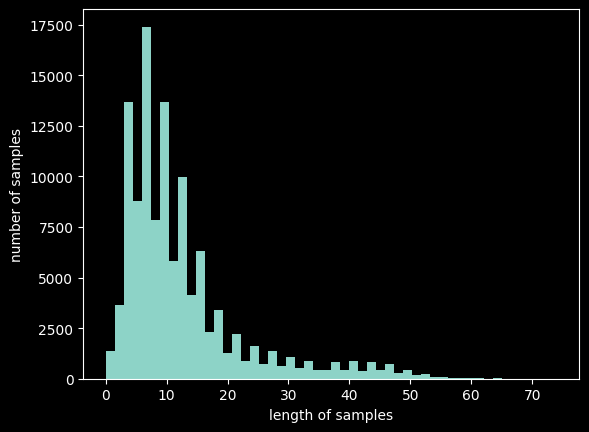

In [56]:
# 패딩
print('리뷰의 최대 길이 :', max(len(review) for review in encoded_X_train))
print('리뷰의 평균 길이 :', sum(map(len, encoded_X_train))/len(encoded_X_train))

plt.hist([len(review) for review in encoded_X_train], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

In [57]:
# 전체 샘플 중 길이가 max_len 이하인 샘플의 비율 확인하는 함수
def below_threshold_len(max_len, nested_list):
    count = 0 
    for sentence in nested_list:
        if len(sentence) <= max_len:
            count +=1
    print(f'전체 샘플 중 길이가 {max_len} 이하인 샘플의 비율 : {(count/len(nested_list))*100}')

In [ ]:
max_len = 30 # 위의 분포 그래프보고 대략 30으로 설정
below_threshold_len(max_len, X_train)

전체 샘플 중 길이가 30 이하인 샘플의 비율 : 92.49703389101914


In [59]:
# 모든 샘플 길이 30으로 맞추는 함수
def pad_sequences(sentences, max_len):
    features = np.zeros((len(sentences), max_len), dtype=int)
    for index, sentence in enumerate(sentences):
        if len(sentence) != 0:
            features[index, : len(sentence)] = np.array(sentence)[:max_len]
    return features

padded_X_train = pad_sequences(encoded_X_train, max_len=max_len)
padded_X_valid = pad_sequences(encoded_X_valid, max_len=max_len)
padded_X_test = pad_sequences(encoded_X_test, max_len=max_len)

print('훈련 데이터의 크기 :', padded_X_train.shape)
print('검증 데이터의 크기 :', padded_X_valid.shape)
print('테스트 데이터의 크기 :', padded_X_test.shape)

훈련 데이터의 크기 : (116314, 30)
검증 데이터의 크기 : (29079, 30)
테스트 데이터의 크기 : (48852, 30)


In [60]:
print('첫번째 샘플의 길이 :', len(padded_X_train[0]))
print('첫번째 샘플 :', padded_X_train[0])


첫번째 샘플의 길이 : 30
첫번째 샘플 : [ 924 1866  128    7   80   48   34    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0]


In [64]:
# !pip install torch

In [65]:
# LSTM을 이용한 네이버 영화 리뷰 분류 모델
import torch
import torch.nn as nn
import torch.nn.functional as F

In [66]:
device = torch.device('mps')
device

device(type='mps')

In [67]:
# 레이블 데이터를 텐서 타입으로 변환
train_label_tensor = torch.tensor(np.array(y_train))
valid_label_tensor = torch.tensor(np.array(y_valid))
test_label_tensor = torch.tensor(np.array(y_test))
print(train_label_tensor[:5])                                 

tensor([0, 1, 1, 1, 1])


## LSTM
### 입력층 : (배치 크기, 문장 길이)
### 임베딩층 : (배치 크기, 문장 길이, 임베딩 벡터의 차원)
### 마지막 시점의 hidden state 값을 출력층과 연결 -> 마지막 hidden state만 있음
### 출력층 : (배치 크기, 은닉 상태의 차원) 
### 소프트맥스 : (배치 크기, 분류하고자 하는 카테고리의 수)

- 단어 벡터의 차원 = 100
- 문장 길이 = 500
- 배치 크기 = 32
- 데이터 개수 = 20000
- LSTM의 은닉층의 크기 = 128
- 분류하고자 하는 카테고리 개수 = 2개

(32,500) -> 입력데이터형태 -> 임베딩 층 통과 후 -> (32,500,100) -> LSTM 통과 후 -> (32,128) -> softmax 출력층 통과 후 -> (32,2)


In [68]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(TextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)
    def forward(self,x):
        # x: (batch_size, seq_length)
        embedded = self.embedding(x) # (batch_size, seq_length, embedding_dim)
        # LSTM은 (hidden state, cell state)의 튜플 반환
        lstm_out, (hidden, cell) = self.lstm(embedded) # lstm_out: (batch_size, seq_length, hidden_dim), hidden: (1,batch_size,hidden_dim)
        last_hidden = hidden.squeeze(0) # (batch_size, hidden_dim)
        logits = self.fc(last_hidden) # (batch_size, output_dim)
        return logits

In [69]:
# 훈련데이터, 검증데이터, 테스트데이터에 대해 파이토치 텐서로 변환하고 배치 단위 연산을 위해 데이터로더로 변환
encoded_train = torch.tensor(padded_X_train).to(torch.int64)
train_dataset = torch.utils.data.TensorDataset(encoded_train,train_label_tensor)
train_dataloader = torch.utils.data.DataLoader(train_dataset, shuffle=True, batch_size =32)

encoded_test = torch.tensor(padded_X_test).to(torch.int64)
test_dataset = torch.utils.data.TensorDataset(encoded_test , test_label_tensor)
test_dataloader = torch.utils.data.DataLoader(test_dataset, shuffle=True, batch_size = 1)

encoded_valid = torch.tensor(padded_X_valid).to(torch.int64)
valid_dataset = torch.utils.data.TensorDataset(encoded_valid, valid_label_tensor)
valid_dataloader = torch.utils.data.DataLoader(valid_dataset, shuffle=True, batch_size=1)

total_batch = len(train_dataloader)
print(f'총 배치의 수 : {total_batch}')

총 배치의 수 : 3635


In [70]:
embedding_dim = 100
hidden_dim = 128
output_dim = 2
learning_rate = 0.01
num_epochs = 10

model = TextClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [74]:
# 평가 코드 작성
def calculate_accuracy(logits, labels): # 모델 정확도 측정
    # _, predicted = torch.max(logits,1)
    predicted = torch.argmax(logits, dim=1)
    correct = (predicted == labels).sum().item()
    total = labels.size(0)
    accuracy = correct / total
    return accuracy

def evaluate(model, valid_dataloader, criterion, device):
    val_loss = 0
    val_correct = 0
    val_total = 0

    model.eval()
    with torch.no_grad():
        # 데이터로더로부터 배치 크기만큼의 데이터를 연속으로 로드
        for batch_X, batch_y in valid_dataloader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            # 모델의 예측값
            logits = model(batch_X)
            # 손실 계산
            loss = criterion(logits, batch_y)
            # 정확도와 손실 계산
            val_loss += loss.item()
            val_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
            val_total += batch_y.size(0)
        val_accuracy = val_correct / val_total
        val_loss /= len(valid_dataloader)
    return val_loss, val_accuracy

In [75]:
# 학습
num_epochs = 5
# training loop
best_val_loss = float('inf')

for epoch in range(num_epochs):
    train_loss = 0
    train_correct = 0
    train_total = 0
    model.train()
    for batch_X, batch_y in train_dataloader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        # batch_X.shape == (batch_size, max_len)
        logits = model(batch_X)
        loss = criterion(logits, batch_y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += calculate_accuracy(logits, batch_y) * batch_y.size(0)
        train_total += batch_y.size(0)
    train_accuracy = train_correct / train_total
    train_loss /= len(train_dataloader)

    # validation
    val_loss, val_accuracy = evaluate(model, valid_dataloader,criterion, device)

    print(f'Epoch {epoch+1}/{num_epochs}:')
    print(f'Train Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.4f}')
    print(f'Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}')

    # 검증 손실이 최소일 때 체크포인트 저장
    if val_loss < best_val_loss:
        print(f'Validation loss improved from {best_val_loss:.4f} to {val_loss:.4f}. 체크포인트를 저장합니다.')
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_model_checkpoint.pth')

Epoch 1/5:
Train Loss: 0.3217, Train Accuracy: 0.8612
Validation Loss: 0.3437, Validation Accuracy: 0.8510
Validation loss improved from inf to 0.3437. 체크포인트를 저장합니다.
Epoch 2/5:
Train Loss: 0.2607, Train Accuracy: 0.8921
Validation Loss: 0.3437, Validation Accuracy: 0.8525
Epoch 3/5:
Train Loss: 0.2050, Train Accuracy: 0.9184
Validation Loss: 0.3689, Validation Accuracy: 0.8522
Epoch 4/5:
Train Loss: 0.1538, Train Accuracy: 0.9410
Validation Loss: 0.4278, Validation Accuracy: 0.8478
Epoch 5/5:
Train Loss: 0.1139, Train Accuracy: 0.9581
Validation Loss: 0.4614, Validation Accuracy: 0.8461


In [76]:
# 모델 로드 및 평가
model.load_state_dict(torch.load('best_model_checkpoint.pth'))
model.to(device)

# 검증 데이터에 대한 정확도와 손실 계산
val_loss, val_accuracy = evaluate(model, valid_dataloader, criterion, device)

print(f'Best model validation loss: {val_loss:.4f}')
print(f'Best model validation accuracy: {val_accuracy:.4f}')

Best model validation loss: 0.3437
Best model validation accuracy: 0.8510


In [77]:
# 테스트 데이터에 대한 정확도와 손실 계산
test_loss, test_accuracy = evaluate(model, test_dataloader, criterion, device)

print(f'Best model test loss: {test_loss:.4f}')
print(f'Best model test accuracy: {test_accuracy:.4f}')

Best model test loss: 0.3470
Best model test accuracy: 0.8491


In [83]:
# 모델 테스트
# 임의의 입력에 대해서 예측을 하는 함수
index_to_tag = {0: '부정', 1: '긍정'}

def predict(text, model, word_to_index, index_to_tag):
    model.eval()
    tokens = mecab.morphs(text)
    tokens = [word for word in tokens if not word in stopwords]
    token_indices = [word_to_index.get(token, 1) for token in tokens]
    input_tensor = torch.tensor([token_indices], dtype=torch.long).to(device)

    with torch.no_grad():
        logits = model(input_tensor) # (1, output_dim)
    predicted_index = torch.argmax(logits, dim=1)
    predicted_tag = index_to_tag[predicted_index.item()]
    return predicted_tag

In [84]:
test_input = "이 영화 개꿀잼 ㅋㅋㅋ"
predict(test_input, model, word_to_index, index_to_tag)

'긍정'

In [85]:
test_input = "이딴게 영화냐 ㅉㅉ"
predict(test_input, model, word_to_index, index_to_tag)

'부정'

In [86]:
test_input = "감독 뭐하는 놈이냐?"
predict(test_input, model, word_to_index, index_to_tag)


'부정'

In [87]:
test_input = "와 개쩐다 정말 세계관 최강자들의 영화다"
predict(test_input, model, word_to_index, index_to_tag)


'긍정'